# 04 · Organelles

**Panel:** EEA1, GM130, Giantin, LAMP1, DDX6, Calreticulin, GRP78, Pmp70, Mitochondria,
Lamin A/B1

Early endosomes (EEA1), Golgi (GM130 for *cis*-Golgi, Giantin), lysosomes (LAMP1),
P-bodies (DDX6), ER (Calreticulin, GRP78), peroxisomes (Pmp70), mitochondria and the
nuclear envelope.

This is the panel where **texture matters most**. A lysosome marker is not informative
because it is bright — it is informative because it is *punctate*. Two cells with
identical mean LAMP1 can have very different lysosomal organisation, and only the
Haralick features can tell them apart. That is why [Step 9](../part3_analysis/1_preparation/01_columns_to_markers.ipynb) kept 2,262 texture
columns rather than dropping them.

The structure is the same as [chapter 01](01_signaling.ipynb); only the panel and the
biology change.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

THEME = "organelles"

wells = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"))
markers = analysis.panel_markers(THEME, wells.columns)
print(f"{len(markers)} markers: {', '.join(markers)}")

11 markers: EEA1, GM130, Giantin, LAMP1, DDX6, Calreticulin, GRP78, Pmp70, Mitochondria, LaminA, LaminB1


In [2]:
lookup = cells.var[cells.var.marker.isin(markers) & (cells.var.statistic == "mean_intensity")]
lookup[["marker", "round", "channel"]].sort_values("round").reset_index(drop=True)

,marker,round,channel
0,EEA1,3,FITC
1,GM130,4,Texas Red
2,Mitochondria,15,FITC
3,Pmp70,17,Cy5
4,GRP78,18,Texas Red
5,Giantin,20,FITC
6,LAMP1,21,Cy5
7,DDX6,25,Cy5
8,LaminA,27,Cy5
9,LaminB1,27,Texas Red


## Effects per condition

In control-well standard deviations, against the DMSO wells of the same timepoint.
PMA is excluded throughout — [Step 16](../part3_analysis/1_preparation/03_normalisation.ipynb) showed it moves every marker by 4–11 SD, so
leaving it in would make every heatmap a picture of PMA.

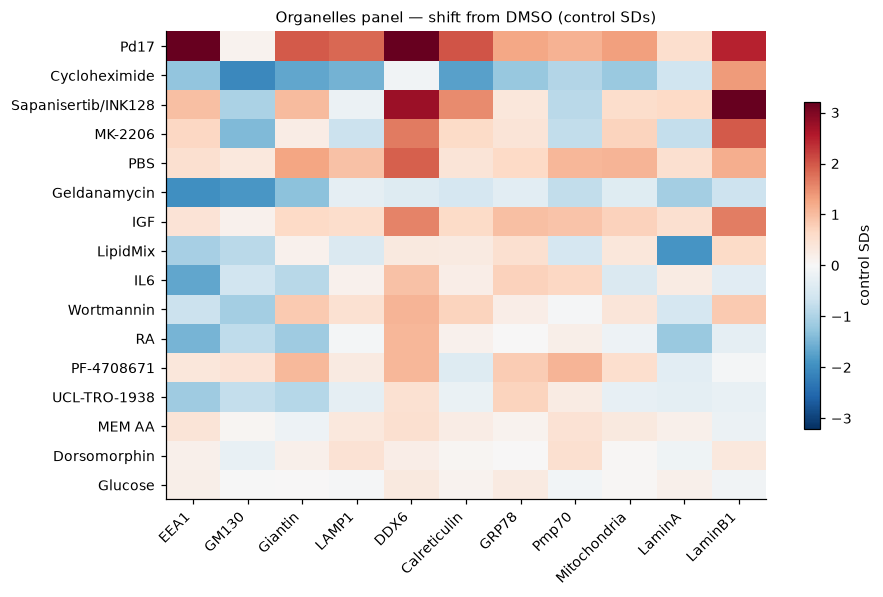

In [3]:
effects = analysis.effect_table(wells, markers, by_timepoint=False)
effects = effects.drop(index=analysis.OUTLIER_CONDITION, errors="ignore")
order = effects.abs().mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8.5, 5.5))
matrix = effects.loc[order]
limit = np.nanpercentile(np.abs(matrix.values), 99)
im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set(yticks=range(len(order)), yticklabels=order)
ax.set_xticks(range(len(markers)))
ax.set_xticklabels(markers, rotation=45, ha="right")
ax.set_title(f"{THEME.capitalize()} panel — shift from DMSO (control SDs)")
fig.colorbar(im, ax=ax, shrink=0.7, label="control SDs")
fig.tight_layout()

## Ranked effects

In [4]:
ranked = analysis.rank_effects(wells, markers)
ranked.head(12).round(3)

,condition,marker,shift,n_wells,p,p_floor,abs_shift,at_p_floor
0,Pd17,EEA1,3.765,12,0.000,0.0,3.765,False
1,Sapanisertib/INK128,LaminB1,3.268,12,0.000,0.0,3.268,False
2,Pd17,DDX6,3.196,12,0.000,0.0,3.196,False
3,Sapanisertib/INK128,DDX6,2.761,12,0.001,0.0,2.761,False
4,Pd17,LaminB1,2.464,12,0.000,0.0,2.464,False
5,Cycloheximide,GM130,-2.077,12,0.000,0.0,2.077,False
6,Pd17,Calreticulin,2.020,12,0.002,0.0,2.020,False
7,Pd17,Giantin,1.976,12,0.001,0.0,1.976,False
8,MK-2206,LaminB1,1.969,12,0.001,0.0,1.969,False
9,Geldanamycin,EEA1,-1.959,12,0.003,0.0,1.959,False


### What the data says

**Pd17 is the biggest organelle mover**, raising DDX6 (+3.1) and EEA1 (+2.3). DDX6
marks P-bodies, the cytoplasmic granules where untranslated mRNA is stored; more DDX6
signal is consistent with translational repression and mRNA being parked rather than
read.

**The same three kinase inhibitors keep appearing** — INK128, MK-2206, Pd17 — moving
Lamin B1 and DDX6. Organelle content is not independent of growth signaling, because
how much Golgi or how many lysosomes a cell maintains is a function of how fast it is
growing.

**Look at what did *not* move.** GM130 and Giantin both mark the Golgi and should
largely agree; where they do not, ask whether one antibody is simply noisier (chapter
02 measured a per-marker control SD for exactly this purpose) before concluding that
the *cis*- and *medial*-Golgi diverged.

## An embedding of this theme alone

variance explained: [0.47  0.142 0.101 0.069]


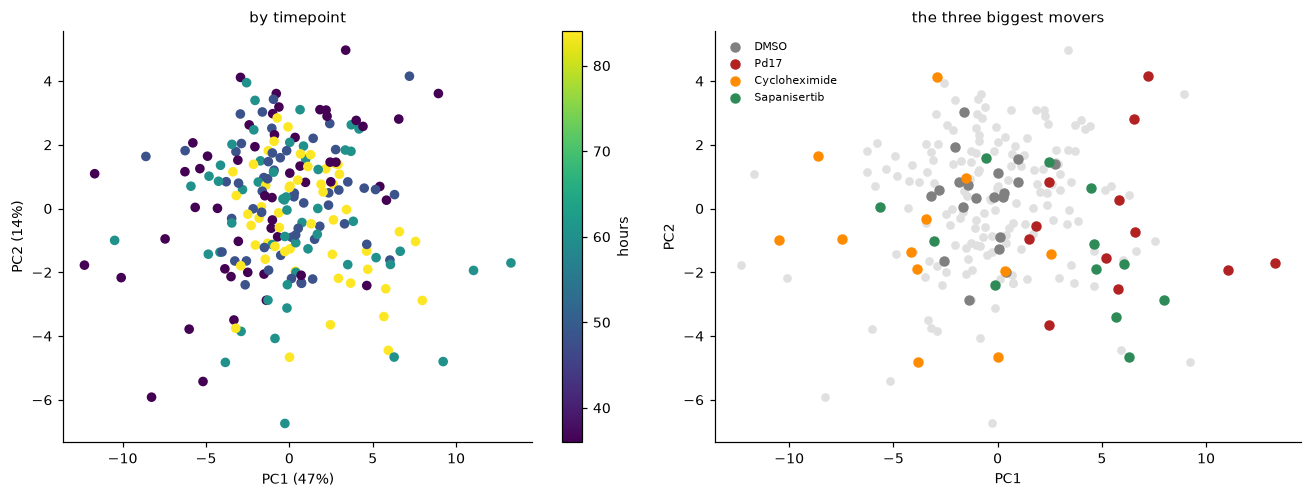

In [5]:
from sklearn.decomposition import PCA

usable = wells[wells.condition != analysis.OUTLIER_CONDITION]
matrix = usable[markers].fillna(0).values
pca = PCA(n_components=4, random_state=0).fit(matrix)
coords = pca.transform(matrix)
print("variance explained:", pca.explained_variance_ratio_[:4].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
scatter = axes[0].scatter(coords[:, 0], coords[:, 1], c=usable.timepoint.values,
                          cmap="viridis", s=28)
axes[0].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", title="by timepoint")
fig.colorbar(scatter, ax=axes[0], label="hours")

top = list(effects.abs().mean(axis=1).sort_values(ascending=False).head(3).index)
axes[1].scatter(coords[:, 0], coords[:, 1], c="0.88", s=22)
for condition, colour in zip(["DMSO"] + top, ["0.5", "firebrick", "darkorange", "seagreen"]):
    mask = (usable.condition == condition).values
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=colour, s=34,
                    label=condition.split("/")[0][:22])
axes[1].set(xlabel="PC1", ylabel="PC2", title="the three biggest movers")
axes[1].legend(fontsize=7)
fig.tight_layout()

In [6]:
loadings = pd.DataFrame(pca.components_[:2].T, index=markers, columns=["PC1", "PC2"])
loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).round(2)

,PC1,PC2
DDX6,0.43,-0.02
Giantin,0.41,-0.38
EEA1,0.38,-0.30
LaminB1,0.36,-0.21
LAMP1,0.29,0.40
Calreticulin,0.28,0.24
Mitochondria,0.23,-0.23
Pmp70,0.21,0.43
GM130,0.21,0.21
GRP78,0.19,0.06


## Single cells over time

The well means say the average moved. The single-cell distributions say whether every
cell moved a little or a subpopulation moved a lot.

organelle-exclusive markers: ['DDX6', 'EEA1', 'GM130', 'Giantin', 'LAMP1']
strongest such effect: Pd17 on EEA1 (+3.76 control SDs)


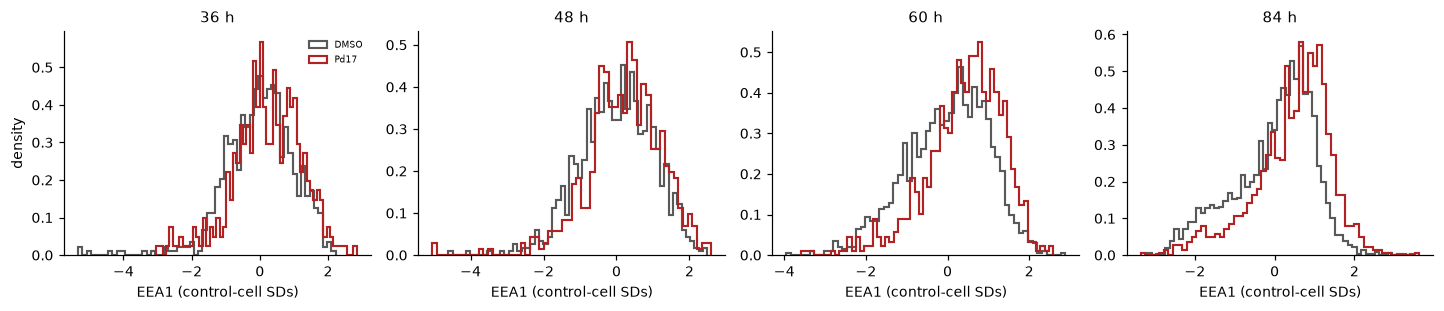

In [7]:
# Lamin B1 tops the raw ranking, but it also sits in the mechanics panel and was
# already shown there. Pick the strongest effect on a marker that belongs to THIS
# theme alone, so the figure says something new.
shared = set().union(*(set(panels.markers(t)) for t in panels.THEMES if t != THEME))
exclusive = ranked[~ranked.marker.isin(shared)]
top_pair = exclusive.iloc[0]
marker, condition = top_pair["marker"], top_pair["condition"]
print(f"organelle-exclusive markers: {sorted(set(markers) - shared)}")
print(f"strongest such effect: {condition} on {marker} "
      f"({top_pair['shift']:+.2f} control SDs)")

column = cells.var.index[(cells.var.marker == marker)
                         & (cells.var.statistic == "mean_intensity")
                         & (cells.var.family == "Intensity")][0]
frame = pd.DataFrame({
    "value": np.asarray(cells[:, column].X).ravel(),
    "condition": cells.obs.condition.astype(str).values,
    "timepoint": cells.obs.timepoint_h.astype(int).values,
})

fig, axes = plotting.panel_grid(4, ncols=4, size=(3.3, 2.9))
for ax, timepoint in zip(axes, [36, 48, 60, 84]):
    block = frame[frame.timepoint == timepoint]
    for name, colour in [("DMSO", "0.35"), (condition, "firebrick")]:
        values = block.loc[block.condition == name, "value"]
        ax.hist(values, bins=60, histtype="step", density=True,
                color=colour, linewidth=1.4, label=name.split("/")[0][:18])
    ax.set(title=f"{timepoint} h", xlabel=f"{marker} (control-cell SDs)")
    if timepoint == 36:
        ax.set_ylabel("density")
        ax.legend(fontsize=6)
fig.tight_layout()

## One number for the theme

In [8]:
summary = analysis.theme_summary(wells, markers)
summary.drop(index=analysis.OUTLIER_CONDITION, errors="ignore").head(8).round(2)

condition
Pd17                   1.78
Cycloheximide          1.25
Sapanisertib/INK128    1.20
MK-2206                0.90
PBS                    0.90
Geldanamycin           0.88
IGF                    0.80
LipidMix               0.64
dtype: float32

In [9]:
summary.to_frame(THEME).to_parquet(H5AD_SLIM.with_name(f"theme_{THEME}.parquet"))
print(f"saved theme summary for {THEME}")

saved theme summary for organelles


---

**Next:** [05 · Integration](05_integration.ipynb).